## Dynamic Pricing Algorithm

### Import necessary library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the Dataset

In [2]:
fitness_data = pd.read_excel("Cleaned_Preprocessed_Dataset_Yogeshwar Tribhuvan.xlsx")

### Create a New Price Column

In [3]:
fitness_data["NewPrice"] = fitness_data["Price (INR)"].astype(float)

### Convert Date Format

In [4]:
fitness_data["BookingEndDate"] = pd.to_datetime(fitness_data["BookingEndDate"])

fitness_data["DayName"] = fitness_data["BookingEndDate"].dt.day_name()

fitness_data["Hour"] = pd.to_datetime(
    fitness_data["BookingStartTime"].astype(str)
).dt.hour

### Create Session Feature

In [5]:
def session(hour):
    if hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    else:
        return "Evening"

fitness_data["Session"] = fitness_data["Hour"].apply(session)

### Calculate Booking Rate

In [6]:
fitness_data["BookingRate"] = (
    fitness_data["Number Booked"] /
    fitness_data["MaxBookees"]
)

### Identify Weekend Classes

In [7]:
fitness_data["IsWeekend"] = fitness_data["DayName"].isin(
    ["Saturday", "Sunday"]
)

### Verify the Dataset

In [8]:
fitness_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3289 entries, 0 to 3288
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ActivitySiteID       3289 non-null   str           
 1   ActivityDescription  3289 non-null   str           
 2   BookingEndDate       3289 non-null   datetime64[us]
 3   BookingStartTime     3289 non-null   datetime64[us]
 4   MaxBookees           3289 non-null   int64         
 5   Number Booked        3289 non-null   int64         
 6   Price (INR)          3289 non-null   int64         
 7   NewPrice             3289 non-null   float64       
 8   DayName              3289 non-null   str           
 9   Hour                 3289 non-null   int32         
 10  Session              3289 non-null   str           
 11  BookingRate          3289 non-null   float64       
 12  IsWeekend            3289 non-null   bool          
dtypes: bool(1), datetime64[us](2), float64(2), i

### Apply Dynamic Pricing Rules

In [9]:
def dynamic_price(row):
    price = row["Price (INR)"]

    if row["BookingRate"] >= 0.80:
        return price * 1.20

    elif row["BookingRate"] <= 0.40:
        return price * 0.90

    elif row["Session"] == "Evening":
        return price * 1.10

    elif row["IsWeekend"]:
        return price * 1.05

    else:
        return price

fitness_data["NewPrice"] = fitness_data.apply(dynamic_price, axis=1)

### Calculate Price Increase

In [10]:
fitness_data["PriceIncrease"] = (
    fitness_data["NewPrice"] -
    fitness_data["Price (INR)"]
)

### Display Updated Prices

In [11]:
fitness_data[[
    "ActivityDescription",
    "Price (INR)",
    "NewPrice",
    "BookingRate",
    "Session"
]].head(20)

,ActivityDescription,Price (INR),NewPrice,BookingRate,Session
0,20-20-20 2.45pm-3.45pm,499,523.95,0.480000,Afternoon
1,20-20-20 2.45pm-3.45pm,499,523.95,0.600000,Afternoon
2,20-20-20 2.45pm-3.45pm,499,523.95,0.560000,Afternoon
3,20-20-20 2.45pm-3.45pm,499,449.10,0.360000,Afternoon
4,20-20-20 2.45pm-3.45pm,499,449.10,0.280000,Afternoon
5,20-20-20 2.45pm-3.45pm,499,449.10,0.400000,Afternoon
6,20-20-20 2.45pm-3.45pm,499,449.10,0.280000,Afternoon
7,20-20-20 2.45pm-3.45pm,499,449.10,0.120000,Afternoon
8,20-20-20 7.00-8.00pm,499,548.90,0.416667,Evening
9,20-20-20 7.00-8.00pm,499,548.90,0.500000,Evening


### Compare Average Prices

In [12]:
print("Original Average Price :",
      fitness_data["Price (INR)"].mean())

print("New Average Price :",
      fitness_data["NewPrice"].mean())

Original Average Price : 1850.231377318334
New Average Price : 1906.5871389480085


### Visualize Price Comparison

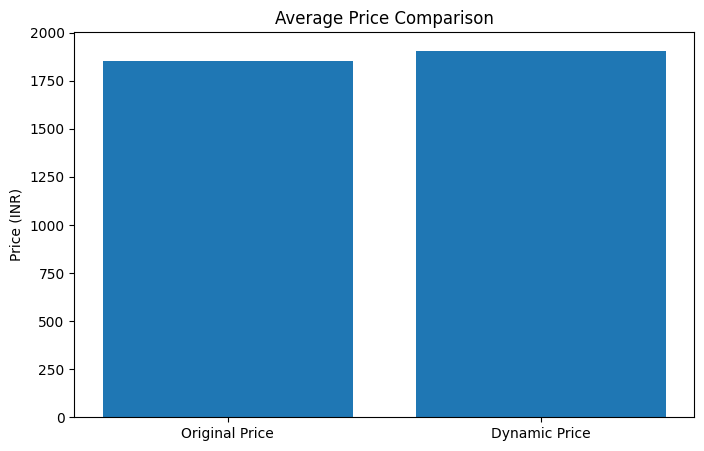

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Original Price", "Dynamic Price"],
    [
        fitness_data["Price (INR)"].mean(),
        fitness_data["NewPrice"].mean()
    ]
)

plt.title("Average Price Comparison")
plt.ylabel("Price (INR)")
plt.show()

### View Final Dynamic Pricing Results

In [14]:
fitness_data[[
    "ActivityDescription",
    "Price (INR)",
    "BookingRate",
    "Session",
    "NewPrice"
]].head(10)

,ActivityDescription,Price (INR),BookingRate,Session,NewPrice
0,20-20-20 2.45pm-3.45pm,499,0.480000,Afternoon,523.95
1,20-20-20 2.45pm-3.45pm,499,0.600000,Afternoon,523.95
2,20-20-20 2.45pm-3.45pm,499,0.560000,Afternoon,523.95
3,20-20-20 2.45pm-3.45pm,499,0.360000,Afternoon,449.10
4,20-20-20 2.45pm-3.45pm,499,0.280000,Afternoon,449.10
5,20-20-20 2.45pm-3.45pm,499,0.400000,Afternoon,449.10
6,20-20-20 2.45pm-3.45pm,499,0.280000,Afternoon,449.10
7,20-20-20 2.45pm-3.45pm,499,0.120000,Afternoon,449.10
8,20-20-20 7.00-8.00pm,499,0.416667,Evening,548.90
9,20-20-20 7.00-8.00pm,499,0.500000,Evening,548.90
